c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 79s 1ms/step - accuracy: 0.9969 - loss: 0.0106 - val_accuracy: 0.9995 - val_loss: 0.0016
Epoch 2/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.9996 - val_loss: 0.0012
Epoch 3/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.9997 - val_loss: 0.0010
Epoch 4/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 77s 1ms/step - accuracy: 0.9997 - loss: 8.9812e-04 - val_accuracy: 0.9997 - val_loss: 9.2543e-04
Epoch 5/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step - accuracy: 0.9997 - loss: 8.0060e-04 - val_accuracy: 0.9997 - val_loss: 0.0011
Epoch 6/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step - accuracy: 0.9997 - loss: 7.4070e-04 - val_accuracy: 0.9997 - val_loss: 9.2268e-04
Epoch 7/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 77s 1ms/step - accuracy: 0.9998 - loss: 7.1970e-04 - val_accuracy: 0.9997 - val_loss: 0.0010
Epoch 8/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 7

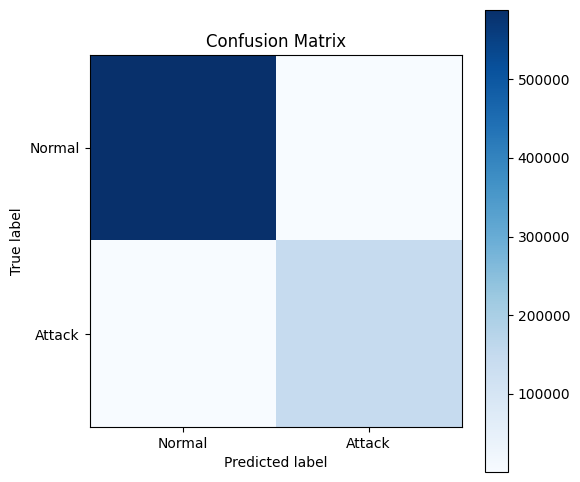

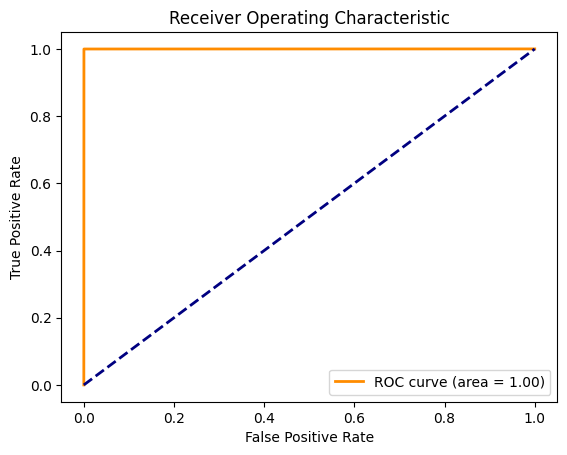

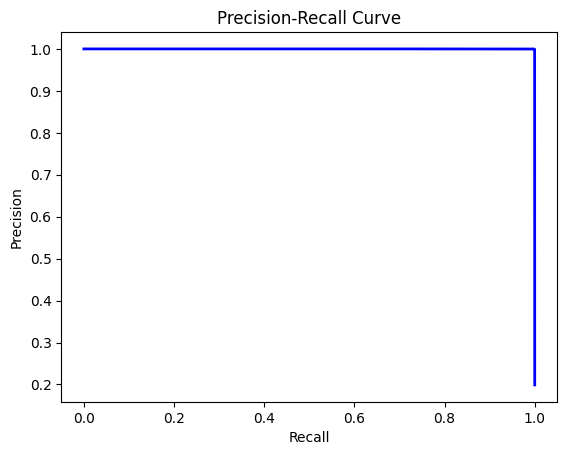

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, precision_recall_curve, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load and preprocess the dataset
data_url = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz"
column_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 
                'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 
                'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 
                'num_outbound_cmds', 'is_hot_login', 'is_guest_login', 'count', 'srv_count', 
                'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 
                'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
                'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
                'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
                'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']

# Load data
df = pd.read_csv('kddcup.data', header=None, names=column_names)
df.columns = [f"feature_{i}" for i in range(df.shape[1] - 1)] + ["class"]

# Binary classification: Normal vs Attack
df['class'] = df['class'].apply(lambda x: 'normal' if x == 'normal.' else 'attack')

# Encode categorical features and labels
label_encoder = LabelEncoder()
df['class'] = label_encoder.fit_transform(df['class'])

categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Normalize continuous features
scaler = MinMaxScaler()
df[df.columns[:-1]] = scaler.fit_transform(df[df.columns[:-1]])

# Split the dataset into train, validation, and test sets
X = df[df.columns[:-1]].values
y = df['class'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Reshape data for LSTM input (samples, timesteps=1, features)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Build the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=10,
                    batch_size=64)

# Evaluate on test set
y_pred_proba = model.predict(X_test).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
classes = ['Normal', 'Attack']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure()
plt.plot(recall_vals[:], precision_vals[:], color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()
